# Forecast trading strategy

---

Get the forecasted values of the trades in future given Monte Carlo simulation of underlying stock based on Heston process.

In [1]:
import sys
sys.path.append('../')

import seaborn as sns
from datetime import date

from stockhealth.analyzer import TimeSeries as Ts
from stockhealth.analyzer import Trade, Transaction, TransactionType
from stockhealth.model import BlackScholes as Bs
from stockhealth.model import _NUMBER_OF_CALENDAR_DAYS_PER_YEAR as _NCD
from stockhealth.training import Trends
from stockhealth.simulation import MonteCarlosWithHeston as Heston
from stockhealth.simulation import Derivative as OptionsFuture
from stockhealth.utilities.graph import plot as ProbabilityPlot

In [2]:
stock = Ts(ticker='SPY')
mdl = Trends(stock=stock)
sim_stock = Heston(trained_model=mdl, number_of_days=13)

In [3]:
call_chain = stock.options_chain__(
    expiry_date=date(2021, 12, 17),
    type_of_transaction=TransactionType.call,
    interest_rate=0.01,
)
put_chain = stock.options_chain__(
    expiry_date=date(2021, 12, 17),
    type_of_transaction=TransactionType.put,
    interest_rate=0.01,
)

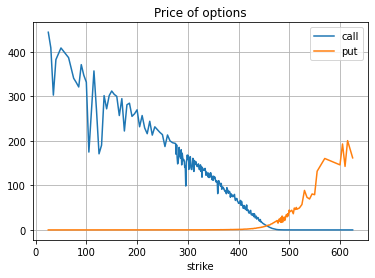

In [4]:
chain_property = 'lastPrice'
axs = call_chain[chain_property].plot(grid=True, label='call')
put_chain[chain_property].plot(grid=True, ax=axs, label='put')
axs.set_title('Price of options')
axs.legend()

In [5]:
option1 = Bs(
    S=mdl.history['latest close'],
    K=435,
    T=17/_NCD,
    r=0.01,
    q=stock.dividend_yield,
)
option2 = Bs(
    S=mdl.history['latest close'],
    K=434,
    T=17/_NCD,
    r=0.01,
    q=stock.dividend_yield,
)
option3 = Bs(
    S=mdl.history['latest close'],
    K=500,
    T=17/_NCD,
    r=0.01,
    q=stock.dividend_yield,
)
option4 = Bs(
    S=mdl.history['latest close'],
    K=501,
    T=17/_NCD,
    r=0.01,
    q=stock.dividend_yield,
)

In [6]:
sim_option1 = OptionsFuture(option=option1, simulation_of_underlying=sim_stock, put_price=put_chain['lastPrice'].loc[option1.K])
sim_option2 = OptionsFuture(option=option2, simulation_of_underlying=sim_stock, put_price=put_chain['lastPrice'].loc[option2.K])
sim_option3 = OptionsFuture(option=option3, simulation_of_underlying=sim_stock, call_price=call_chain['lastPrice'].loc[option3.K])
sim_option4 = OptionsFuture(option=option4, simulation_of_underlying=sim_stock, call_price=call_chain['lastPrice'].loc[option4.K])

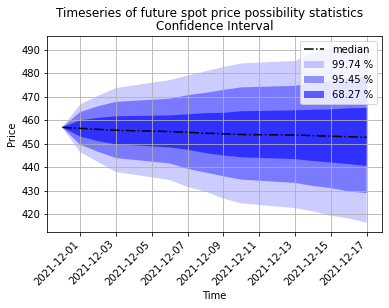

In [7]:
sim_stock.solve()
f_s, a_o = sim_stock.plot()

In [8]:
sim_option1.solve()
sim_option2.solve()
sim_option3.solve()
sim_option4.solve()

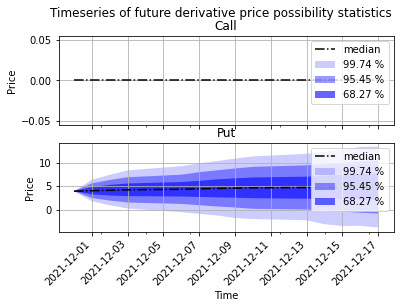

In [9]:
f_o1, a_o1 = sim_option1.plot()

In [10]:
iron_condor = Trade(
    Transaction(simulation=sim_stock, amount=0),
    Transaction(simulation=sim_option1, amount=-1),
    Transaction(simulation=sim_option2, amount=1),
    Transaction(simulation=sim_option3, amount=-1),
    Transaction(simulation=sim_option4, amount=1),
)
trade = iron_condor

Text(0.5, 0.98, 'Timeseries forecast of the trade with confidence interval')

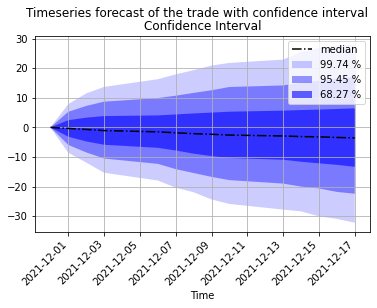

In [11]:
f_trade, a_trade = ProbabilityPlot(trade.price - trade.price.iloc[0].mean())
f_trade.suptitle('Timeseries forecast of the trade with confidence interval')

Text(0.5, 1.0, 'CDF of the P/L at the expiry date')

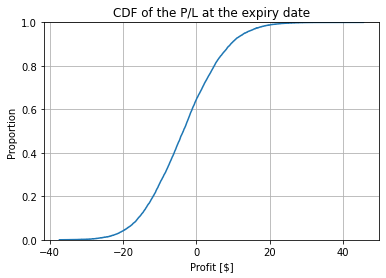

In [12]:
a_profit = sns.ecdfplot((trade.price - trade.price.iloc[0].mean()).iloc[-1])
a_profit.grid(True)
a_profit.set_xlabel('Profit [$]')
a_profit.set_title('CDF of the P/L at the expiry date')

Text(0.5, 1.0, 'PDF of the P/L at expiry')

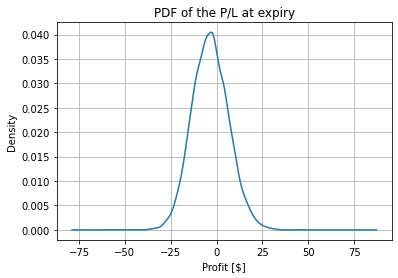

In [13]:
a_pdf = ((trade.price - trade.price.iloc[0].mean()).iloc[-1]).plot.kde(grid=True)
a_pdf.set_xlabel('Profit [$]')
a_pdf.set_title('PDF of the P/L at expiry')

In [14]:
expected_return = ((trade.price - trade.price.iloc[0]).mean()).iloc[-1].mean()
print('Expected return on this trade is $' + str(round(expected_return, 2)))

Expected return on this trade is $-8.36
